# Detección de neumonía en radiografías de tórax mediante CNN

## Introducción

En este proyecto vamos a trabajar con el dataset **RSNA Pneumonia Detection Challenge**, un conjunto de radiografías de tórax utilizado para estudiar la detección automática de neumonía mediante técnicas de aprendizaje profundo.

Aunque la competición original estaba planteada como un problema de detección y localización de lesiones, en este trabajo vamos a adaptar el problema a una versión más simple y alineada con el contenido visto en clase: una **clasificación binaria**.

El objetivo será predecir si una radiografía corresponde a:
- **0 = no neumonía**
- **1 = neumonía**

Este enfoque encaja mejor con la lógica explicada en el tema de **Convolutional Neural Networks (CNN)**, ya que nos permitirá trabajar con:
- imágenes médicas,
- convoluciones,
- pooling,
- extracción de características,
- clasificación final.

Además, más adelante podremos comparar una CNN sencilla con un modelo preentrenado y añadir visualizaciones para interpretar mejor los resultados.

## Objetivos del notebook

1. Montar Google Drive y acceder al dataset.
2. Descomprimir el archivo ZIP.
3. Explorar la estructura de carpetas y archivos.
4. Leer las etiquetas del reto.
5. Transformar el problema original en una tarea de clasificación binaria.
6. Crear una tabla limpia con rutas de imagen y etiquetas.

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)

# Montar Google Drive

Como el archivo ZIP del dataset está guardado en Google Drive, primero montamos la unidad para poder acceder a él desde Colab.

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Definir la ruta del archivo ZIP en Google Drive

El archivo comprimido del dataset se encuentra en la carpeta `Trabajos` dentro de `Mi unidad`. Por tanto, definimos esa ruta para poder utilizarlo en el notebook.

In [4]:
zip_path = "/content/drive/MyDrive/Trabajos/rsna-pneumonia-detection-challenge.zip"
print(zip_path)

/content/drive/MyDrive/Trabajos/rsna-pneumonia-detection-challenge.zip


# Comprobar que el archivo existe

Antes de descomprimir el ZIP, verificamos que la ruta es correcta y que Colab puede encontrar el archivo.

In [5]:
extract_path = "/content/rsna_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset descomprimido en:", extract_path)

Dataset descomprimido en: /content/rsna_dataset


# Inspección inicial del contenido

Una vez extraído el dataset, observamos qué carpetas y archivos contiene. Esto nos permite entender cómo está organizada la información.

In [6]:
os.listdir(extract_path)

['GCP Credits Request Link - RSNA.txt',
 'stage_2_train_images',
 'stage_2_sample_submission.csv',
 'stage_2_train_labels.csv',
 'stage_2_test_images',
 'stage_2_detailed_class_info.csv']

# Definición de las rutas principales

En el dataset vamos a trabajar principalmente con:
- la carpeta de imágenes de entrenamiento,
- la carpeta de imágenes de test,
- el archivo de etiquetas de entrenamiento,
- y el archivo con información más detallada de las clases.

In [7]:
train_images_path = os.path.join(extract_path, "stage_2_train_images")
test_images_path = os.path.join(extract_path, "stage_2_test_images")
labels_csv_path = os.path.join(extract_path, "stage_2_train_labels.csv")
class_info_csv_path = os.path.join(extract_path, "stage_2_detailed_class_info.csv")

print("Train images path:", train_images_path)
print("Test images path:", test_images_path)
print("Labels CSV path:", labels_csv_path)
print("Detailed class info CSV path:", class_info_csv_path)

Train images path: /content/rsna_dataset/stage_2_train_images
Test images path: /content/rsna_dataset/stage_2_test_images
Labels CSV path: /content/rsna_dataset/stage_2_train_labels.csv
Detailed class info CSV path: /content/rsna_dataset/stage_2_detailed_class_info.csv


# Comprobación de las rutas principales

Antes de seguir, verificamos que las carpetas y archivos clave del dataset existen realmente.

In [8]:
print("Train images:", os.path.exists(train_images_path))
print("Test images:", os.path.exists(test_images_path))
print("Labels CSV:", os.path.exists(labels_csv_path))
print("Detailed class info CSV:", os.path.exists(class_info_csv_path))

Train images: True
Test images: True
Labels CSV: True
Detailed class info CSV: True


# Cargar el archivo de etiquetas

Ahora leemos el archivo `stage_2_train_labels.csv`, que contiene las anotaciones utilizadas en la competición. En el problema original, este CSV incluye coordenadas de bounding boxes y una variable llamada `Target` que indica si existe neumonía.

In [9]:
labels_df = pd.read_csv(labels_csv_path)
labels_df.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


# Dimensiones del archivo de etiquetas

Comprobamos cuántas filas y columnas tiene el archivo para hacernos una idea inicial de su tamaño.

In [10]:
labels_df.shape

(30227, 6)

# Nombres de las columnas

Mostramos los nombres de las columnas para entender qué variables tenemos disponibles.

In [12]:
labels_df.columns.tolist()

['patientId', 'x', 'y', 'width', 'height', 'Target']

# Mostrar algunas filas aleatorias

Además de las primeras filas, resulta útil ver ejemplos aleatorios para entender mejor la estructura general del archivo.

In [13]:
labels_df.sample(5, random_state=42)

,patientId,x,y,width,height,Target
10189,6d25fc2c-d0b3-4b4b-850f-dea71042576a,NaN,NaN,NaN,NaN,0
19102,b2541f48-1acf-4f33-b604-8665fc1517c8,179.0,581.0,169.0,183.0,1
25427,e3d0271b-b53f-4d6b-9e99-57fab7644798,NaN,NaN,NaN,NaN,0
423,07755c77-1391-49f1-8fdb-832082887aec,NaN,NaN,NaN,NaN,0
2041,231de9e8-63d9-4093-9d57-2bdcdee49225,292.0,486.0,130.0,250.0,1


# Explicación de la transformación del problema

En el archivo de etiquetas puede ocurrir que un mismo paciente aparezca varias veces, especialmente cuando hay varias anotaciones. Para convertir este problema en una clasificación binaria simple, agruparemos por `patientId` y tomaremos el valor máximo de `Target`.

Así:
- si un paciente tiene al menos una fila con `Target = 1`, la etiqueta final será positiva,
- si todas las filas tienen `Target = 0`, la etiqueta final será negativa.

In [14]:
binary_df = labels_df.groupby("patientId")["Target"].max().reset_index()
binary_df.head()

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,000924cf-0f8d-42bd-9158-1af53881a557,0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1
3,000fe35a-2649-43d4-b027-e67796d412e0,1
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1


# Número de pacientes únicos

Una vez agrupado por paciente, comprobamos cuántos estudios únicos tenemos realmente en el dataset.

In [15]:
binary_df.shape

(26684, 2)

# Distribución de clases

En problemas médicos es muy importante comprobar si las clases están equilibradas o desbalanceadas. Por eso contamos cuántos casos hay de neumonía y cuántos de no neumonía.

In [16]:
binary_df["Target"].value_counts()

,count
Target,
0,20672
1,6012


# Visualización de la distribución de clases

Representamos la distribución de clases en un gráfico de barras para interpretarla de forma más visual.

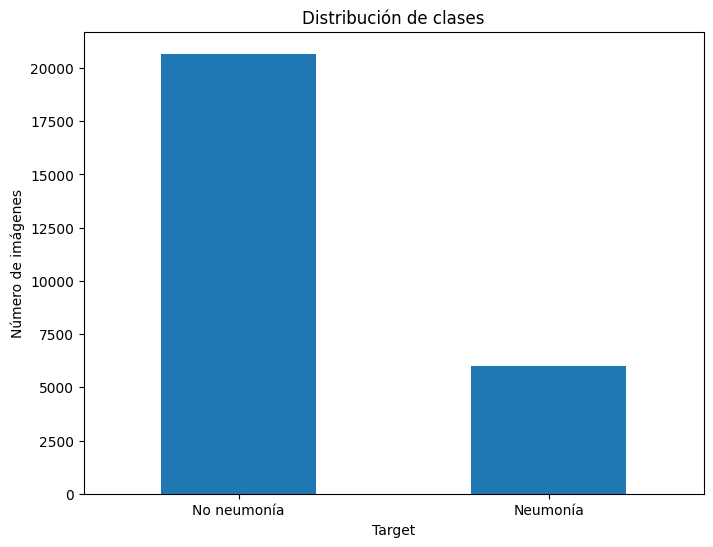

In [17]:
binary_df["Target"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No neumonía", "Neumonía"], rotation=0)
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases")
plt.show()

# Cargar el archivo de información detallada

Además del archivo principal de etiquetas, el dataset incluye otro CSV con clases más detalladas. Esto puede ser útil para enriquecer la exploración y comprender mejor la estructura original del reto.

In [18]:
class_info_df = pd.read_csv(class_info_csv_path)
class_info_df.head()

,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


# Tipos de clase disponibles

Mostramos cuántos ejemplos hay de cada clase detallada para entender mejor cómo se distribuyen los casos en el dataset original.

In [19]:
class_info_df["class"].value_counts()

,count
class,
No Lung Opacity / Not Normal,11821
Lung Opacity,9555
Normal,8851


# Unir la información binaria con la información detallada

Ahora combinamos la tabla binaria con el archivo de clase detallada. De esta forma tendremos en una misma tabla:
- el identificador del paciente,
- la etiqueta binaria,
- y la clase detallada.

In [20]:
merged_df = binary_df.merge(class_info_df, on="patientId", how="left")
merged_df.head()

,patientId,Target,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity
3,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity
4,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity


# Construcción de la ruta completa de cada imagen

Las imágenes de entrenamiento están guardadas como archivos DICOM dentro de la carpeta `stage_2_train_images`. Vamos a construir la ruta completa para cada paciente, ya que esto será necesario para cargar las radiografías más adelante.

In [21]:
merged_df["image_path"] = merged_df["patientId"].apply(
    lambda x: os.path.join(train_images_path, f"{x}.dcm")
)

merged_df.head()

,patientId,Target,class,image_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,/content/rsna_dataset/stage_2_train_images/000...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,/content/rsna_dataset/stage_2_train_images/000...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
3,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
4,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...


# Comprobación de existencia de archivos

Verificamos si las rutas generadas apuntan realmente a imágenes existentes. Esto es una buena práctica para detectar errores antes de seguir con el análisis.

In [22]:
merged_df["file_exists"] = merged_df["image_path"].apply(os.path.exists)
merged_df["file_exists"].value_counts()

,count
file_exists,
True,30227


# Crear la tabla final de trabajo

Nos quedamos con una versión más limpia del dataset, que será la base del proyecto. Esta tabla contiene:
- el identificador del paciente,
- la etiqueta binaria,
- la clase detallada,
- y la ruta a la imagen.

In [23]:
dataset_df = merged_df[["patientId", "Target", "class", "image_path"]].copy()
dataset_df.head()

,patientId,Target,class,image_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,/content/rsna_dataset/stage_2_train_images/000...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,/content/rsna_dataset/stage_2_train_images/000...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
3,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
4,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...


# Información general de la tabla final

Comprobamos el tipo de dato de cada columna y el número de valores no nulos para asegurarnos de que la tabla está bien construida.

In [24]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patientId   30227 non-null  object
 1   Target      30227 non-null  int64 
 2   class       30227 non-null  object
 3   image_path  30227 non-null  object
dtypes: int64(1), object(3)
memory usage: 944.7+ KB


# Comprobar valores nulos

Los datasets médicos pueden incluir información incompleta. Por ello, revisamos si hay valores nulos en alguna columna de la tabla final.

In [26]:
dataset_df.isnull().sum()

,0
patientId,0
Target,0
class,0
image_path,0


# Eliminar posibles duplicados

Aunque ya hemos transformado el problema en clasificación binaria, al unir con la información detallada pueden aparecer pacientes repetidos. Para asegurarnos de que la tabla final tenga una sola fila por radiografía, eliminamos duplicados por `patientId`.

In [27]:
dataset_df = dataset_df.drop_duplicates(subset="patientId").reset_index(drop=True)
dataset_df.head()

,patientId,Target,class,image_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,/content/rsna_dataset/stage_2_train_images/000...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,/content/rsna_dataset/stage_2_train_images/000...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/000...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,/content/rsna_dataset/stage_2_train_images/001...


# Comprobar el tamaño final tras eliminar duplicados

Ahora verificamos cuántos pacientes únicos tenemos realmente en la tabla definitiva.

In [28]:
dataset_df.shape

(26684, 4)

# Guardar la tabla procesada

Guardamos la tabla final en un nuevo archivo CSV para tener una versión limpia y reutilizable del dataset ya preparado para clasificación binaria.

In [29]:
output_csv_path = "/content/rsna_binary_dataset.csv"
dataset_df.to_csv(output_csv_path, index=False)
print("Archivo corregido guardado en:", output_csv_path)

Archivo corregido guardado en: /content/rsna_binary_dataset.csv


# Parte 2: carga y visualización de radiografías DICOM

En esta parte del proyecto vamos a trabajar directamente con las imágenes. Como las radiografías están en formato DICOM, primero necesitaremos una librería específica para leer este tipo de archivos médicos.

El objetivo de esta fase es:
- cargar imágenes reales,
- visualizar ejemplos,
- comparar casos con y sin neumonía,
- y entender mejor qué tipo de información visual contiene el dataset.

In [30]:
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.8 MB/s eta 0:00:00


# Importar librerías para trabajar con imágenes DICOM

Usaremos `pydicom` para leer los archivos DICOM y `matplotlib` para visualizar las radiografías.

In [31]:
import pydicom
import matplotlib.pyplot as plt

# Función para cargar una radiografía DICOM

Definimos una función que reciba la ruta de una imagen y devuelva la radiografía como una matriz de píxeles. Esto facilitará reutilizar el código más adelante.

In [32]:
def cargar_dicom(image_path):
    dicom = pydicom.dcmread(image_path)
    image = dicom.pixel_array
    return image

# Mostrar una radiografía de ejemplo

Seleccionamos una imagen del dataset y la visualizamos para comprobar que la lectura DICOM funciona correctamente.

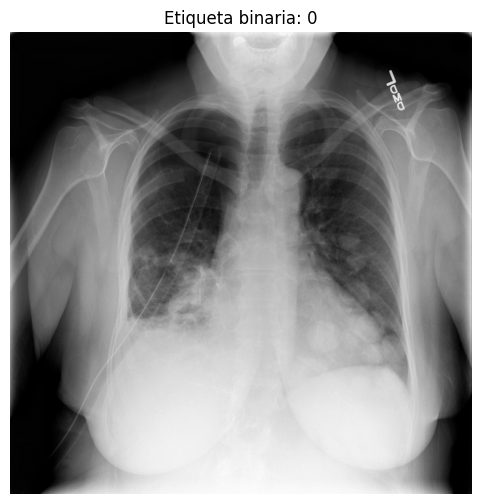

In [33]:
sample_path = dataset_df.loc[0, "image_path"]
sample_label = dataset_df.loc[0, "Target"]

image = cargar_dicom(sample_path)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title(f"Etiqueta binaria: {sample_label}")
plt.axis("off")
plt.show()

# Comprobar las dimensiones de una radiografía

Las imágenes médicas pueden tener resoluciones distintas. Por eso observamos el tamaño de una radiografía para entender mejor el tipo de entrada con el que trabajaremos.

In [34]:
image.shape

(1024, 1024)

# Separar ejemplos positivos y negativos

Ahora vamos a separar algunos casos con neumonía y algunos sin neumonía para comparar visualmente ambos grupos.

In [35]:
positivos_df = dataset_df[dataset_df["Target"] == 1].reset_index(drop=True)
negativos_df = dataset_df[dataset_df["Target"] == 0].reset_index(drop=True)

print("Casos positivos:", len(positivos_df))
print("Casos negativos:", len(negativos_df))

Casos positivos: 6012
Casos negativos: 20672


# Mostrar ejemplos de radiografías con neumonía

Visualizamos varias radiografías etiquetadas como positivas para observar patrones visuales generales.

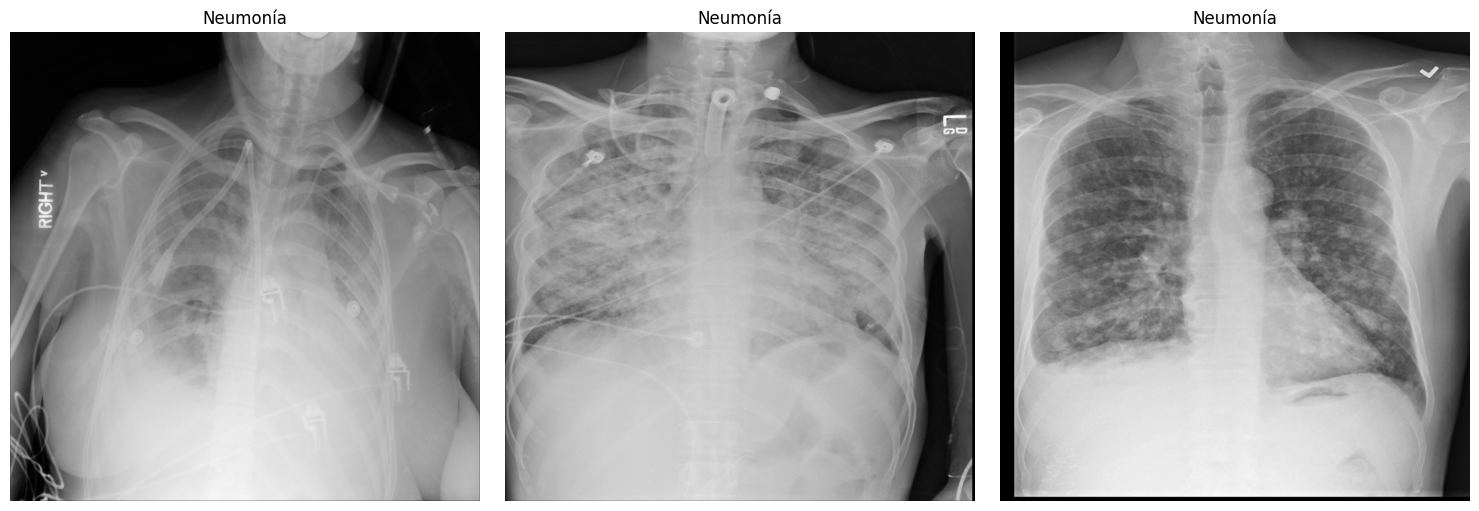

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    path = positivos_df.loc[i, "image_path"]
    img = cargar_dicom(path)
    ax.imshow(img, cmap="gray")
    ax.set_title("Neumonía")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Mostrar ejemplos de radiografías sin neumonía

Ahora visualizamos varios casos negativos para compararlos con los positivos.

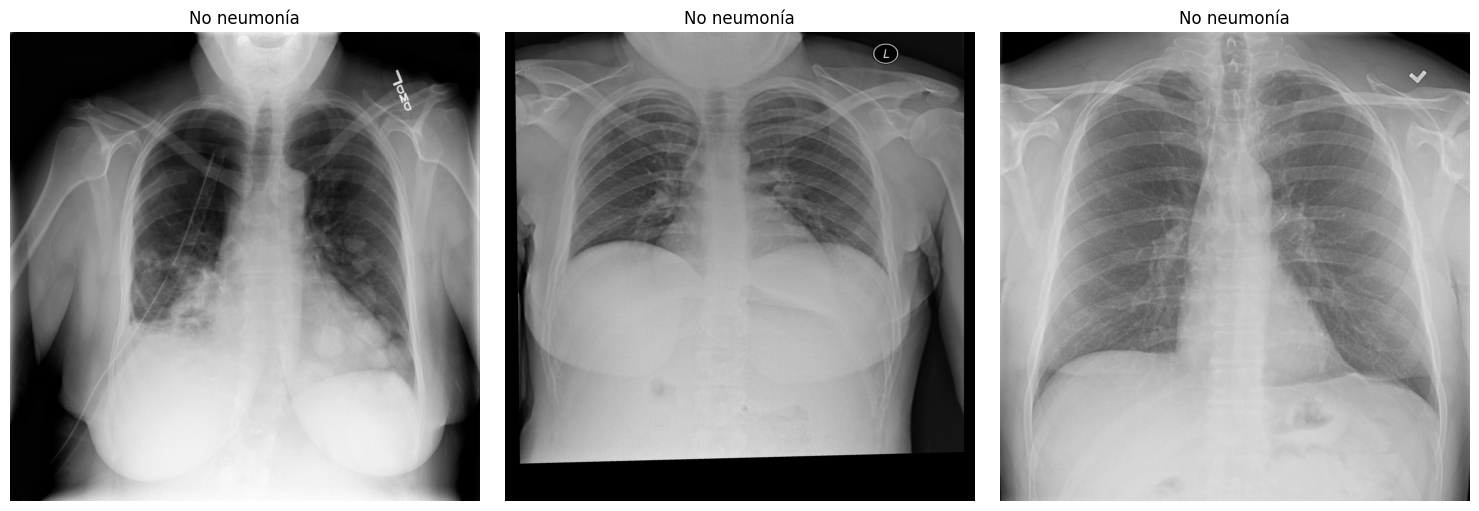

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    path = negativos_df.loc[i, "image_path"]
    img = cargar_dicom(path)
    ax.imshow(img, cmap="gray")
    ax.set_title("No neumonía")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Comparación visual entre clases

Mostramos una comparación directa entre radiografías positivas y negativas. Esto no sustituye el diagnóstico médico, pero ayuda a ver que el problema tiene una base visual que un modelo CNN puede intentar aprender.

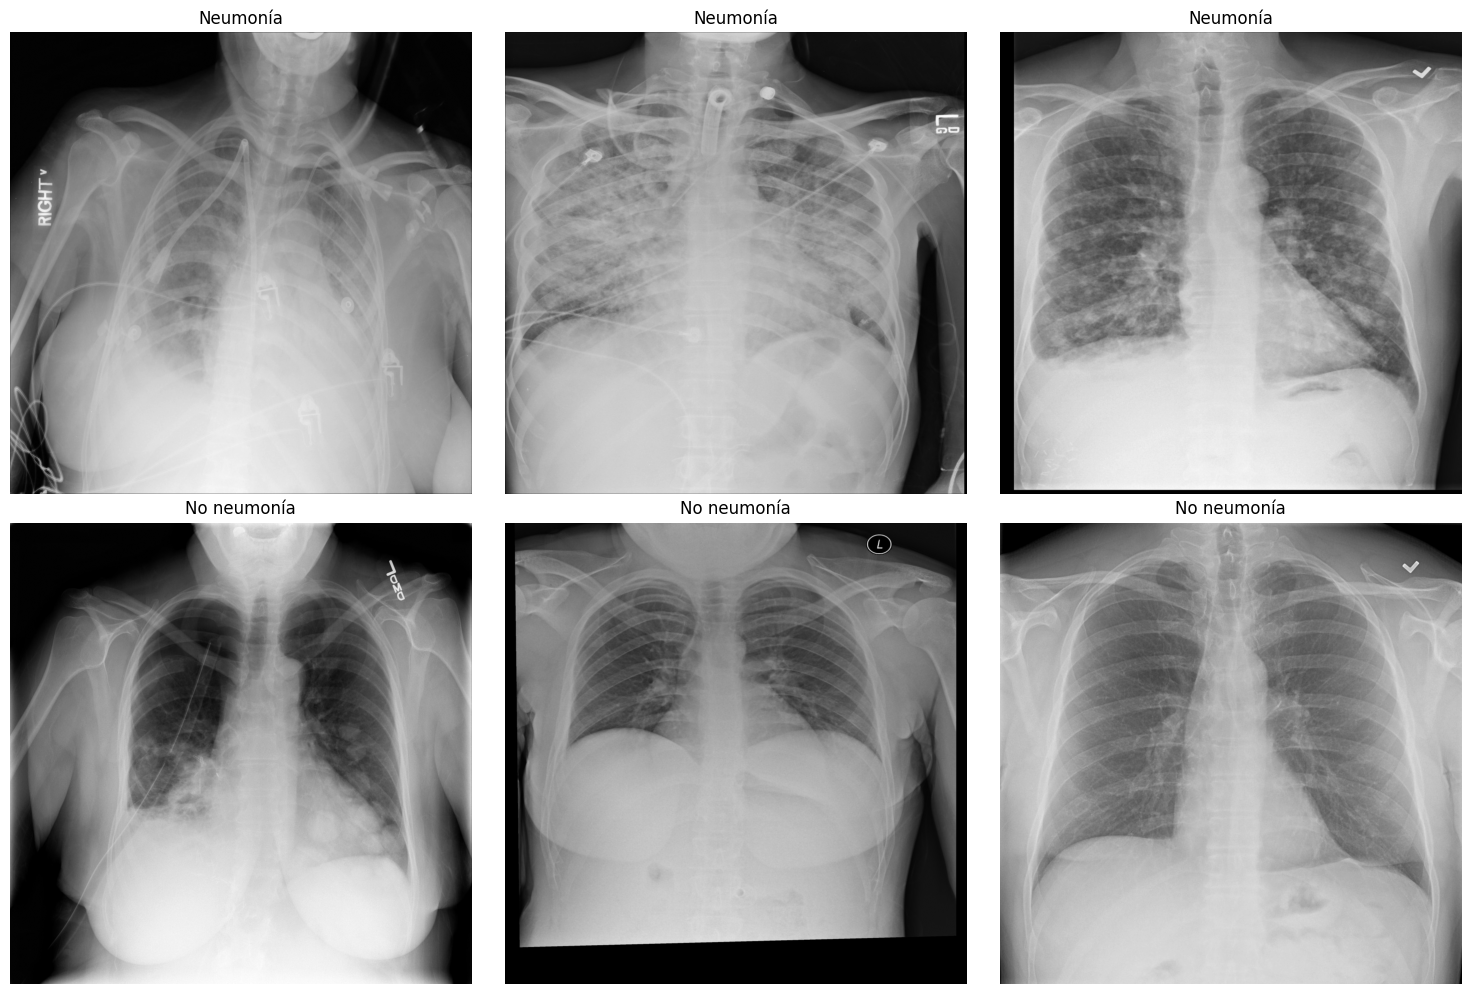

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(3):
    img_pos = cargar_dicom(positivos_df.loc[i, "image_path"])
    axes[0, i].imshow(img_pos, cmap="gray")
    axes[0, i].set_title("Neumonía")
    axes[0, i].axis("off")

    img_neg = cargar_dicom(negativos_df.loc[i, "image_path"])
    axes[1, i].imshow(img_neg, cmap="gray")
    axes[1, i].set_title("No neumonía")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Estadísticos básicos del tamaño de imagen

Calculamos el tamaño de varias radiografías para comprobar si todas tienen la misma resolución o si será necesario redimensionarlas antes del entrenamiento.

In [39]:
sample_sizes = []

for i in range(20):
    path = dataset_df.loc[i, "image_path"]
    img = cargar_dicom(path)
    sample_sizes.append(img.shape)

sample_sizes[:10]

[(1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024)]

# Frecuencia de tamaños observados

Mostramos cuántas veces aparece cada resolución entre una muestra de radiografías.

In [40]:
from collections import Counter
Counter(sample_sizes)

Counter({(1024, 1024): 20})

# Conclusión de la parte visual

En esta parte hemos leído radiografías DICOM reales, visualizado ejemplos positivos y negativos y comprobado el tamaño de las imágenes. Esta exploración es importante porque nos permite entender mejor el tipo de dato con el que trabajaremos y justifica la necesidad de aplicar preprocesado antes de entrenar una CNN.

# Parte 3: preprocesado y preparación de los datos

Después de explorar visualmente las radiografías, el siguiente paso es preparar las imágenes para que puedan ser utilizadas por una red neuronal convolucional.

En general, una CNN necesita que todas las imágenes:
- tengan el mismo tamaño,
- estén en un formato numérico adecuado,
- y estén acompañadas por sus etiquetas.

En esta parte vamos a:
1. convertir las imágenes DICOM en arrays procesables,
2. redimensionarlas a un tamaño común,
3. normalizar los valores de intensidad,
4. dividir el dataset en entrenamiento, validación y test,
5. y dejar listas las matrices que usaremos en el modelo.

In [41]:
import cv2
from sklearn.model_selection import train_test_split

# Definir el tamaño objetivo de las imágenes

Como las radiografías originales tienen resoluciones grandes, vamos a reducirlas a un tamaño fijo. Esto simplifica el problema y reduce el coste computacional.

En este proyecto utilizaremos un tamaño de 128x128 píxeles, que es razonable para una primera CNN.

In [42]:
IMG_SIZE = 128

# Función de preprocesado de una imagen

Definimos una función que realice los pasos básicos de preprocesado:
- leer la radiografía DICOM,
- redimensionarla a 128x128,
- normalizar los valores entre 0 y 1.

Este formato será mucho más adecuado para el entrenamiento de la red.

In [43]:
def preprocesar_imagen(image_path, img_size=IMG_SIZE):
    dicom = pydicom.dcmread(image_path)
    image = dicom.pixel_array.astype(np.float32)

    image = cv2.resize(image, (img_size, img_size))
    image = image / np.max(image)

    return image

# Probar la función de preprocesado con una imagen

Antes de aplicarla a todo el dataset, comprobamos que la función funciona correctamente con una sola radiografía.

In [46]:
sample_image = preprocesar_imagen(dataset_df.loc[0, "image_path"])
sample_image.shape, sample_image.min(), sample_image.max()

((128, 128), np.float32(0.0), np.float32(1.0))

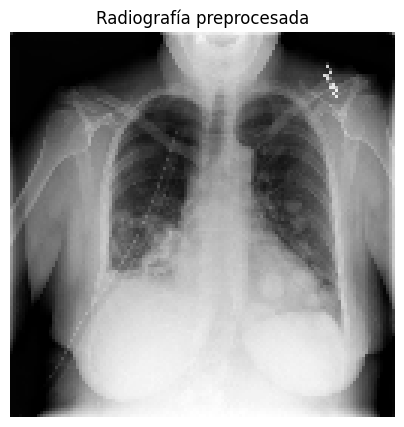

In [47]:
plt.figure(figsize=(5,5))
plt.imshow(sample_image, cmap="gray")
plt.title("Radiografía preprocesada")
plt.axis("off")
plt.show()

# Crear una muestra reducida del dataset

Como el dataset completo es grande, para una primera prueba vamos a trabajar con una muestra más pequeña y equilibrada. Esto permite comprobar que todo funciona antes de lanzar experimentos más pesados.

Tomaremos:
- 1000 casos positivos,
- 1000 casos negativos.

In [48]:
positivos_sample = positivos_df.sample(1000, random_state=42)
negativos_sample = negativos_df.sample(1000, random_state=42)

small_df = pd.concat([positivos_sample, negativos_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
small_df.shape

(2000, 4)

# Comprobar el equilibrio de la muestra

Verificamos que la muestra reducida esté equilibrada entre ambas clases.

In [49]:
small_df["Target"].value_counts()

,count
Target,
0,1000
1,1000


# Preprocesar todas las imágenes de la muestra reducida

Aplicamos la función de preprocesado a cada imagen de la muestra. El resultado será una lista de arrays que convertiremos en una matriz `X`.

In [50]:
X = []
y = []

for _, row in small_df.iterrows():
    img = preprocesar_imagen(row["image_path"])
    X.append(img)
    y.append(row["Target"])

X = np.array(X)
y = np.array(y)

X.shape, y.shape

((2000, 128, 128), (2000,))

# Añadir la dimensión del canal

Aunque las radiografías están en escala de grises, las CNN esperan normalmente una dimensión adicional para el canal. Por ello, transformamos la matriz `X` al formato:

`(n_imágenes, alto, ancho, canales)`

In [51]:
X = np.expand_dims(X, axis=-1)
X.shape

(2000, 128, 128, 1)

# División en entrenamiento, validación y test

Separamos los datos en tres conjuntos:
- entrenamiento,
- validación,
- test.

Esto permitirá entrenar el modelo, ajustar hiperparámetros y evaluar el rendimiento final de forma más fiable.

In [52]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)



Train: (1400, 128, 128, 1) (1400,)
Validation: (300, 128, 128, 1) (300,)
Test: (300, 128, 128, 1) (300,)


# Verificar la distribución de clases en cada partición

Es importante comprobar que la separación mantiene el equilibrio entre las clases.

In [53]:
print("Train:\n", pd.Series(y_train).value_counts())
print("\nValidation:\n", pd.Series(y_val).value_counts())
print("\nTest:\n", pd.Series(y_test).value_counts())

Train:
 0    700
1    700
Name: count, dtype: int64

Validation:
 1    150
0    150
Name: count, dtype: int64

Test:
 1    150
0    150
Name: count, dtype: int64


# Visualizar algunas imágenes del conjunto de entrenamiento

Mostramos varias imágenes junto con su etiqueta binaria para comprobar que todo está correctamente alineado.

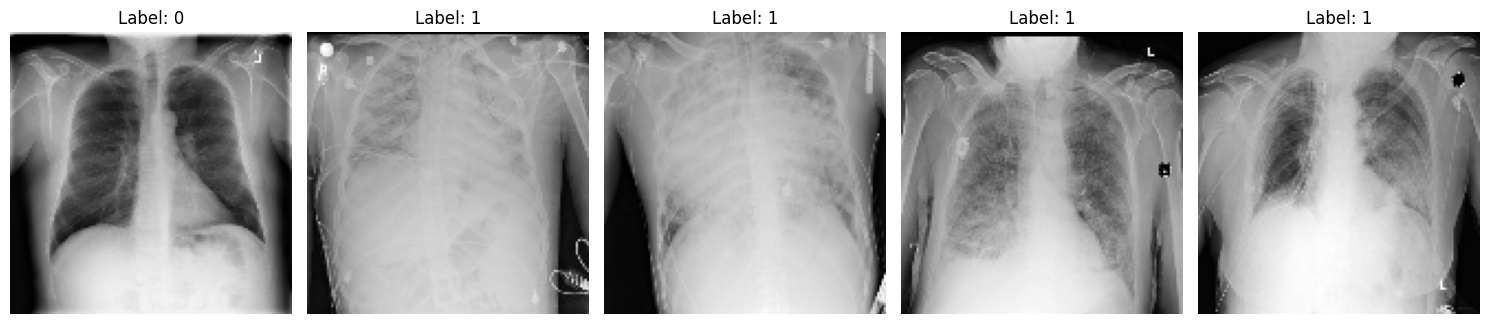

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, ax in enumerate(axes):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Conclusión de la parte de preprocesado

En esta fase hemos preparado una versión reducida y equilibrada del dataset, hemos preprocesado las radiografías, añadido la dimensión de canal y dividido los datos en entrenamiento, validación y test.

Con esto ya tenemos listas las entradas y etiquetas necesarias para entrenar una primera CNN sencilla.

# Parte 4: construcción de una CNN básica

En esta parte vamos a construir una red neuronal convolucional sencilla para clasificar las radiografías en dos clases:
- 0 = no neumonía
- 1 = neumonía

La arquitectura seguirá la lógica explicada en clase:
1. capas de convolución para extraer patrones,
2. capas de max pooling para reducir dimensionalidad,
3. una capa flatten para convertir los mapas de características en un vector,
4. y capas densas finales para realizar la clasificación.

El objetivo no es crear un modelo extremadamente complejo, sino una primera CNN clara, interpretable y coherente.

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Comprobar la forma de entrada

Antes de construir la red, comprobamos la forma de las imágenes de entrenamiento para usarla como `input_shape` del modelo.

In [56]:
X_train.shape

(1400, 128, 128, 1)

# Definir la arquitectura de la CNN

Construimos una CNN básica con:
- dos bloques convolucionales,
- max pooling tras cada bloque,
- una capa flatten,
- una capa densa intermedia,
- y una salida final sigmoide para clasificación binaria.

In [57]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Explicación de la arquitectura

Esta red sigue la lógica básica de una CNN:

- Las capas `Conv2D` extraen patrones locales de la imagen, como bordes, zonas de contraste o texturas.
- Las capas `MaxPooling2D` reducen el tamaño espacial de los mapas de características y conservan la información más relevante.
- La capa `Flatten` transforma los mapas en un vector.
- La capa `Dense` combina la información aprendida.
- La última neurona con activación `sigmoid` devuelve una probabilidad entre 0 y 1.

In [58]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Configurar early stopping

Para evitar sobreentrenamiento, utilizamos `EarlyStopping`. Esta técnica detiene el entrenamiento cuando la pérdida de validación deja de mejorar.

In [59]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Entrenar la CNN

Ahora entrenamos el modelo con los datos de entrenamiento y validación. Guardaremos el historial para poder visualizar después la evolución de la pérdida y la accuracy.

In [60]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 489ms/step - accuracy: 0.5614 - loss: 0.7005 - val_accuracy: 0.7067 - val_loss: 0.6135
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 479ms/step - accuracy: 0.6850 - loss: 0.6006 - val_accuracy: 0.7067 - val_loss: 0.5970
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 467ms/step - accuracy: 0.7100 - loss: 0.5685 - val_accuracy: 0.7033 - val_loss: 0.5962
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step - accuracy: 0.7393 - loss: 0.5265 - val_accuracy: 0.7200 - val_loss: 0.5906
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 474ms/step - accuracy: 0.7700 - loss: 0.4883 - val_accuracy: 0.6900 - val_loss: 0.6317
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 461ms/step - accuracy: 0.8000 - loss: 0.4385 - val_accuracy: 0.7000 - val_loss: 0.6404
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.8200 - loss: 0.3903 - val_accuracy: 0.6567 - val_loss: 0.7221


# Visualizar la evolución de la pérdida

Representamos la función de pérdida en entrenamiento y validación para comprobar si el modelo aprende y si aparece sobreajuste.

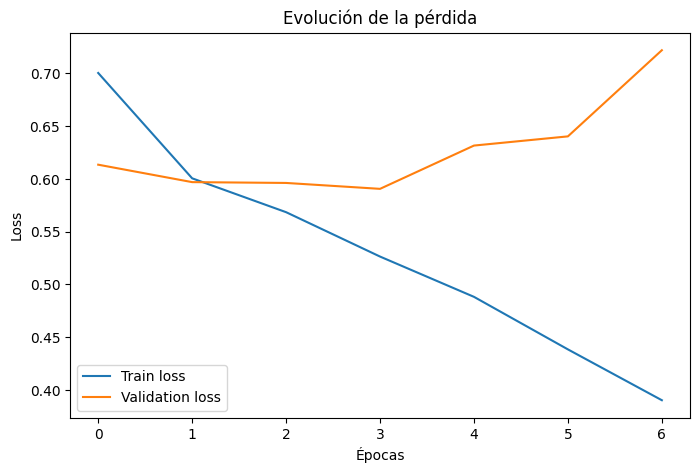

In [61]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualizar la evolución de la accuracy

Además de la pérdida, mostramos la accuracy en entrenamiento y validación.

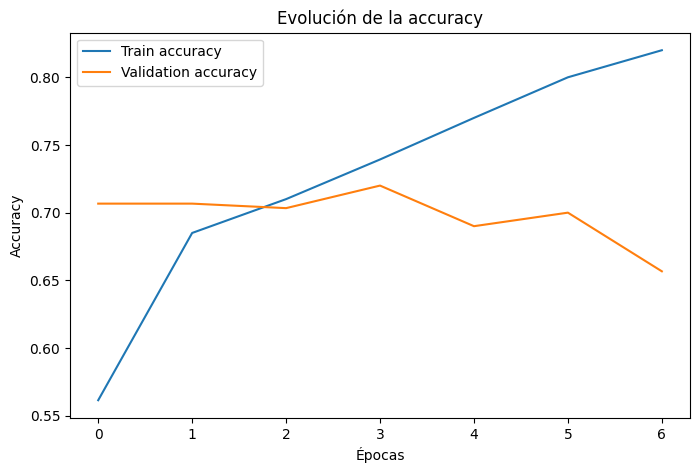

In [62]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluación inicial sobre el conjunto de test

Una vez entrenado el modelo, evaluamos su rendimiento sobre el conjunto de test, que no ha sido usado durante el entrenamiento.

In [63]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.5831328630447388
Test accuracy: 0.6866666674613953


# Obtener probabilidades y predicciones

La red devuelve probabilidades. Para convertirlas en clases binarias, usamos un umbral de 0.5:
- si la probabilidad es mayor o igual que 0.5, predecimos neumonía,
- si es menor que 0.5, predecimos no neumonía.

In [64]:
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).flatten()

y_prob[:5], y_pred[:5]

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


(array([[0.91512024],
        [0.23080452],
        [0.1375491 ],
        [0.59744114],
        [0.55146116]], dtype=float32),
 array([1, 0, 0, 1, 1]))

# Métricas de clasificación

Además de la accuracy, calculamos métricas más informativas para este problema:
- precisión,
- recall,
- F1-score,
- y matriz de confusión.

En problemas médicos, el recall suele ser especialmente importante, ya que mide cuántos casos positivos reales somos capaces de detectar.

In [65]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Informe de clasificación

Mostramos precision, recall y F1-score para cada clase.

In [66]:
print(classification_report(y_test, y_pred, target_names=["No neumonía", "Neumonía"]))

              precision    recall  f1-score   support

 No neumonía       0.68      0.69      0.69       150
    Neumonía       0.69      0.68      0.68       150

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.69      0.69      0.69       300



# Matriz de confusión

La matriz de confusión permite ver cuántos casos han sido correctamente clasificados y en qué tipo de errores falla el modelo.

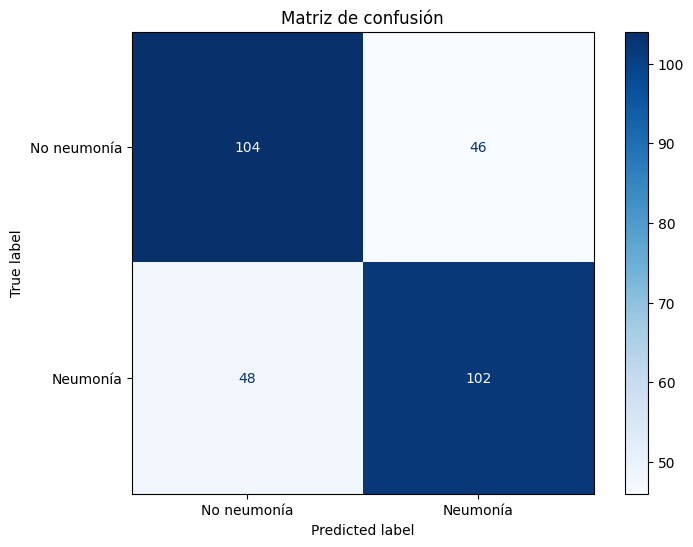

In [67]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No neumonía", "Neumonía"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

# Visualizar algunas predicciones del modelo

Mostramos varias radiografías del conjunto de test junto con su etiqueta real y la predicción obtenida por la CNN.

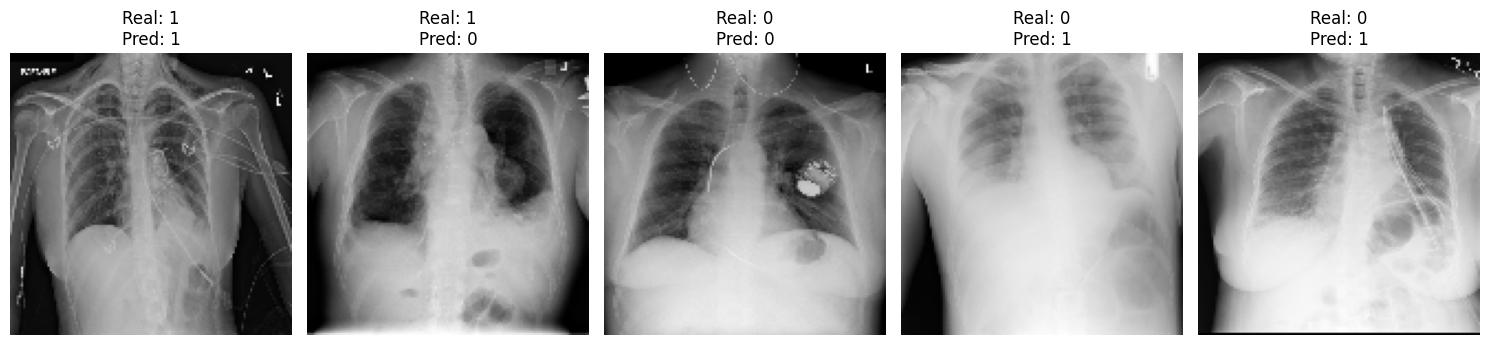

In [68]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, ax in enumerate(axes):
    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"Real: {y_test[i]}\nPred: {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Conclusión de la CNN básica

En esta parte hemos construido una CNN sencilla siguiendo la lógica vista en clase: convolución, pooling, flatten y capas densas finales.

Este modelo ya permite comprobar que una red neuronal convolucional puede aprender patrones visuales útiles a partir de radiografías de tórax. Sin embargo, todavía se trata de una arquitectura relativamente simple, por lo que en la siguiente parte podremos plantear mejoras como:
- aumentar la profundidad del modelo,
- aplicar data augmentation,
- o utilizar transfer learning con un modelo preentrenado.
---

